## OCR (Optical Character Recognition)

This OCR app will be used to extract text from an image of handwritten notes

* Take image (Handwritten Notes)  ---> Process the image (Computer Vision - CV2) ---> LLM (Role assigned as OCR)

In [ ]:
#pip install opencv-python

  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.2 MB 4.2 MB/s eta 0:00:10
   -- ------------------------------------- 2.4/40.2 MB 4.6 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/40.2 MB 4.7 MB/s eta 0:00:08
   ----- ---------------------------------- 5.2/40.2 MB 5.6 MB/s eta 0:00:07
   ------- -------------------------------- 7.3/40.2 MB 6.5 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/40.2 MB 6.9 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/40.2 MB 7.7 MB/s eta 0:00:04
   --------------- ------------------------ 15.5/40.2 MB 8.9 MB/s eta 0:00:03
   ----------------- ---------------------- 17.8/40.2 MB 9.1 MB/s eta 0:00:03
   ------------------- -------------------- 19.9/40.2 MB 9.3 MB/s eta 0:00:03
   ---

In [1]:
import cv2 
import matplotlib.pyplot as plt
import google.generativeai as genai
import os
from PIL import Image

C:\Users\krihn\AppData\Local\Temp\ipykernel_11444\825482996.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
image = cv2.imread('Handwritten_notes.png')   # right now is a BGR image (need to be converted into RGB)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)  # BGR to RGB
image_gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY) # RGB to GRAYSCALE
_,image_bw = cv2.threshold(image,170,255,cv2.THRESH_BINARY)

In [3]:
# Its a colour image (3D)
image_bw.shape

(1152, 1308, 3)

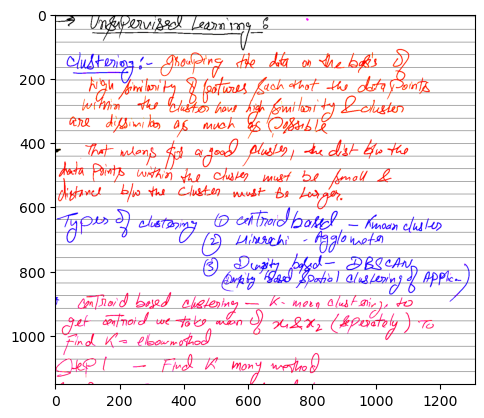

In [4]:
plt.imshow(image_bw)
plt.show()

In [5]:
cv2.imshow('Grey Image',image_gray)
cv2.imshow('B&W Image',image_bw)
cv2.imshow('Color',image)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
# The image that cv2 image has given is numpy array format, we need to convert into image context.

final_image = Image.fromarray(image_bw)

In [14]:
# Configure LLM:

gemini_key = os.getenv('GOOGLE_API_KEY1')
genai.configure(api_key=gemini_key)
model = genai.GenerativeModel('gemini-2.5-flash-lite',
                              generation_config={'temperature':0.5})

In [15]:
prompt = '''
<Role> You are an OCR (Optical Character Recognition) application.
<Gole> Identify the characters in handwritten notes.
<Context> User has provided the image of hand written notes.

<Instructions>
* Do not generate any new content.
* You can create a word which is not recognized.
* Output should be well formatted.'''

In [17]:
response = model.generate_content([prompt,final_image])
print(response.text)

Unsupervised Learning &

Clustering:- Grouping the data on the basis of
high similarity of features such that the data points
within the cluster have high similarity & clusters
are dissimilar as much as possible

* That means for a good cluster, the dist btw the
data points within the cluster must be small &
distance btw the clusters must be larger.

Types of clustering
① centroid based - Kmean clusters
② Hierarchi - Agglomera
③ Density based - DBSCAN
(Density based spatial clustering of Applica)

Centroid based clustering - K-mean clustering, to
get centroid we take mean of x1 & x2 (separately) to
find K = elbow method

Step 1 - Find K mony method


# Extracting text from word

In [1]:
from docx import Document

In [3]:
file = Document('sample_file.docx')

In [5]:
doc_text = ''
for p in file.paragraphs:
    doc_text = doc_text+p.text+'\n'

In [ ]:
#pip install python-docx

Note: you may need to restart the kernel to use updated packages.


# MIME


| File Type   | Extension        | MIME Type                                                                 |
| ----------- | ---------------- | ------------------------------------------------------------------------- |
| Plain text  | `.txt`           | `text/plain`                                                              |
| HTML        | `.html`          | `text/html`                                                               |
| CSV         | `.csv`           | `text/csv`                                                                |
| JSON        | `.json`          | `application/json`                                                        |
| PDF         | `.pdf`           | `application/pdf`                                                         |
| ZIP         | `.zip`           | `application/zip`                                                         |
| JPEG image  | `.jpg` / `.jpeg` | `image/jpeg`                                                              |
| PNG image   | `.png`           | `image/png`                                                               |
| GIF         | `.gif`           | `image/gif`                                                               |
| MP3 audio   | `.mp3`           | `audio/mpeg`                                                              |
| MP4 video   | `.mp4`           | `video/mp4`                                                               |
| Excel       | `.xls`           | `application/vnd.ms-excel`                                                |
| Excel (new) | `.xlsx`          | `application/vnd.openxmlformats-officedocument.spreadsheetml.sheet`       |
| Word        | `.doc`           | `application/msword`                                                      |
| Word (new)  | `.docx`          | `application/vnd.openxmlformats-officedocument.wordprocessingml.document` |